In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
data = pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#EDA


In [13]:
data.shape
data.isnull().sum()
df=data
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

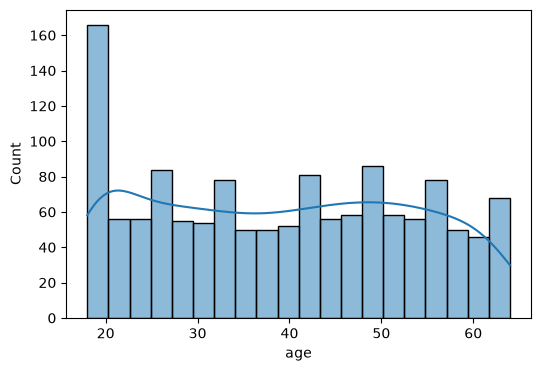

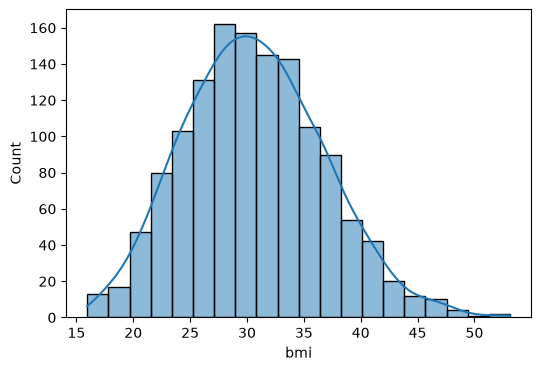

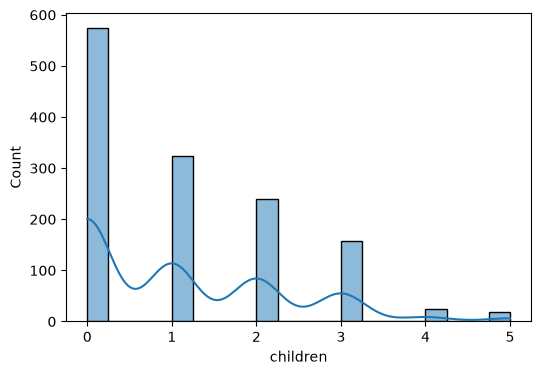

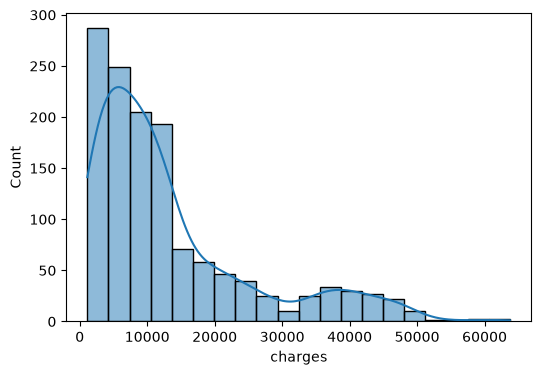

In [19]:
numeric_col = ['age', 'bmi', 'children', 'charges']
for col in numeric_col:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col],kde = True , bins = 20)

<Axes: xlabel='children', ylabel='count'>

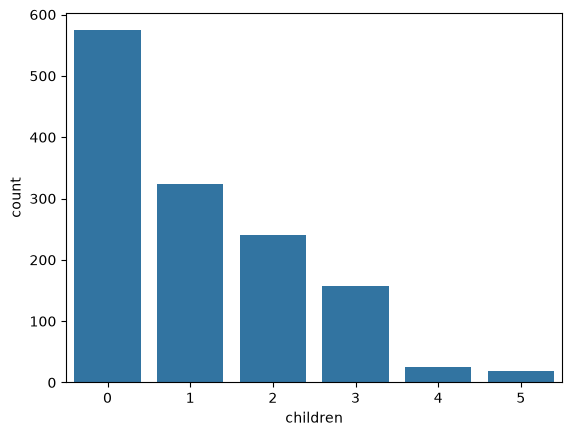

In [20]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

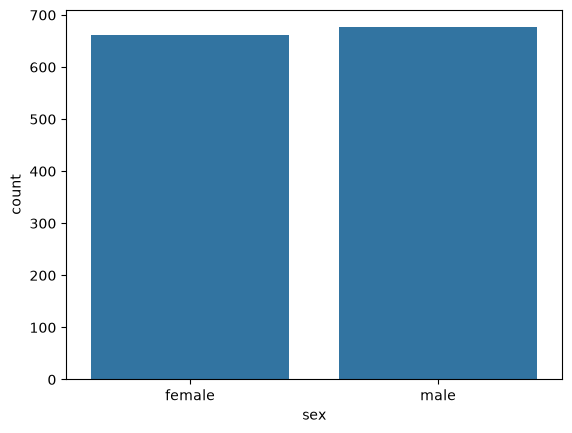

In [21]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

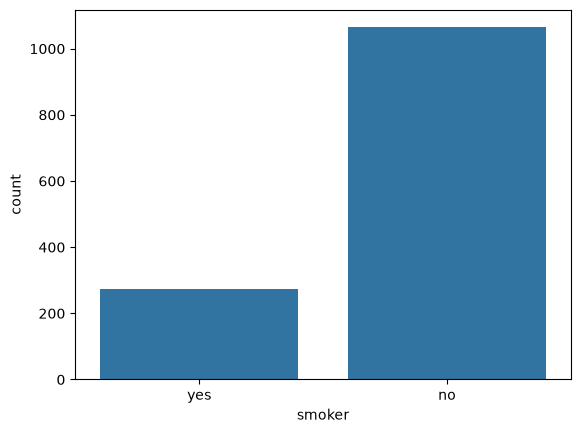

In [22]:
sns.countplot(x = df['smoker'])

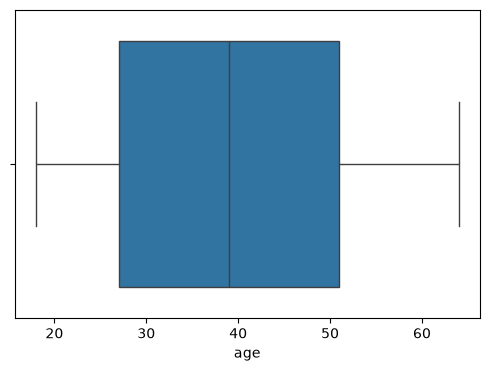

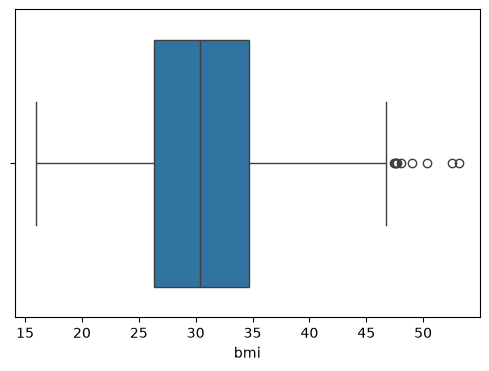

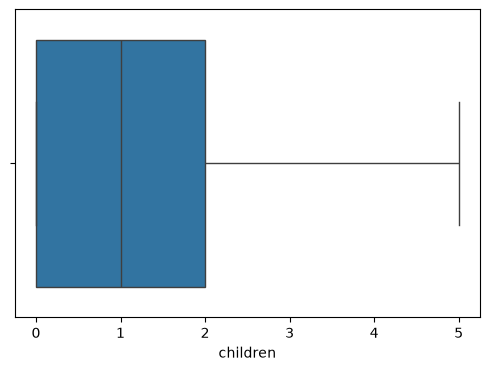

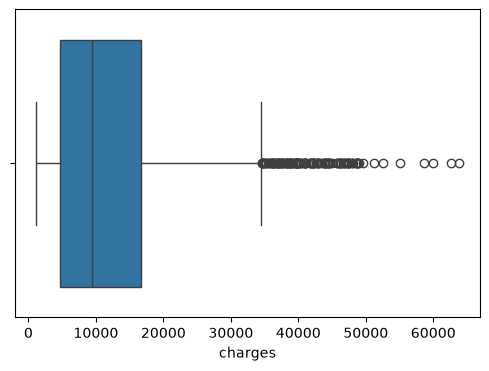

In [25]:
for col in numeric_col:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

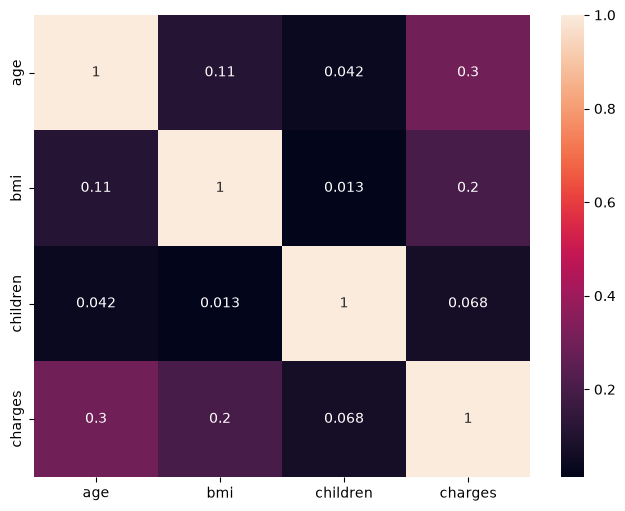

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [30]:
df_cleaned = df.copy()

In [31]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [32]:
df_cleaned.drop_duplicates(inplace = True)

In [33]:
df_cleaned.shape

(1337, 7)

In [34]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [35]:

df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0,"female" : 1})

KeyError: 'sex'

In [39]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [40]:
df_cleaned.rename(columns={
    'sex' :'is_female',
    'smoker': 'is_smoker'
                          },inplace = True)

In [41]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
df['region'].value_counts()
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,False,False,True
1,18,male,33.770,1,no,1725.55230,False,True,False
2,28,male,33.000,3,no,4449.46200,False,True,False
3,33,male,22.705,0,no,21984.47061,True,False,False
4,32,male,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830,True,False,False
1334,18,female,31.920,0,no,2205.98080,False,False,False
1335,18,female,36.850,0,no,1629.83350,False,True,False
1336,21,female,25.800,0,no,2007.94500,False,False,True


In [43]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)

In [45]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,False,False,True
1,18,male,33.770,1,no,1725.55230,False,True,False
2,28,male,33.000,3,no,4449.46200,False,True,False
3,33,male,22.705,0,no,21984.47061,True,False,False
4,32,male,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830,True,False,False
1334,18,female,31.920,0,no,2205.98080,False,False,False
1335,18,female,36.850,0,no,1629.83350,False,True,False
1336,21,female,25.800,0,no,2007.94500,False,False,True


In [51]:
df_cleaned['is_female'] = df_cleaned['is_female'].map({"male" : 0,"female" : 1})

In [52]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,yes,16884.92400,False,False,True
1,18,0,33.770,1,no,1725.55230,False,True,False
2,28,0,33.000,3,no,4449.46200,False,True,False
3,33,0,22.705,0,no,21984.47061,True,False,False
4,32,0,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,10600.54830,True,False,False
1334,18,1,31.920,0,no,2205.98080,False,False,False
1335,18,1,36.850,0,no,1629.83350,False,True,False
1336,21,1,25.800,0,no,2007.94500,False,False,True


In [53]:
df_cleaned['is_smoker'] = df_cleaned['is_smoker'].map({"no" : 0,"yes" : 1})

In [55]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

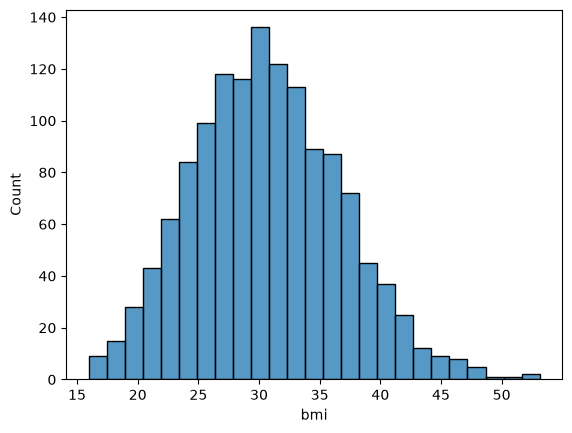

In [56]:
sns.histplot(df['bmi'])

In [62]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [64]:
df_cleaned
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

KeyError: "None of [Index(['bmi_category'], dtype='str')] are in the [columns]"

In [67]:

df_cleaned = df_cleaned.astype(int)

In [68]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0,0,1,0


In [72]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [73]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,0,1,0


In [75]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

ValueError: `x` and `y` must be broadcastable.